Instalization

In [345]:
!pip install scikit-learn-extra
!pip install kmodes
!pip install tensorflow
!pip install scikit-learn


Connect in google drive

In [346]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Importing Libraries

In [347]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as splt
import seaborn
from sklearn import preprocessing
import sklearn_extra.cluster as sce
import tensorflow as tf
import kmodes
from kmodes.kmodes import KModes
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report

Reading the data

In [348]:
df = pd.read_csv('/content/drive/MyDrive/final project/cardio_train.csv',sep=';')
df

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
69995,99993,19240,2,168,76.0,120,80,1,1,1,0,1,0
69996,99995,22601,1,158,126.0,140,90,2,2,0,0,1,1
69997,99996,19066,2,183,105.0,180,90,3,1,0,1,0,1
69998,99998,22431,1,163,72.0,135,80,1,2,0,0,0,1


In [349]:
df.shape

(70000, 13)

Checking for missing values

In [350]:
df.isnull().values.any()

False

In [351]:
df.isna().sum()

id             0
age            0
gender         0
height         0
weight         0
ap_hi          0
ap_lo          0
cholesterol    0
gluc           0
smoke          0
alco           0
active         0
cardio         0
dtype: int64

In [352]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           70000 non-null  int64  
 1   age          70000 non-null  int64  
 2   gender       70000 non-null  int64  
 3   height       70000 non-null  int64  
 4   weight       70000 non-null  float64
 5   ap_hi        70000 non-null  int64  
 6   ap_lo        70000 non-null  int64  
 7   cholesterol  70000 non-null  int64  
 8   gluc         70000 non-null  int64  
 9   smoke        70000 non-null  int64  
 10  alco         70000 non-null  int64  
 11  active       70000 non-null  int64  
 12  cardio       70000 non-null  int64  
dtypes: float64(1), int64(12)
memory usage: 6.9 MB


In [353]:
df.head()

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0


In [354]:
df.tail()

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
69995,99993,19240,2,168,76.0,120,80,1,1,1,0,1,0
69996,99995,22601,1,158,126.0,140,90,2,2,0,0,1,1
69997,99996,19066,2,183,105.0,180,90,3,1,0,1,0,1
69998,99998,22431,1,163,72.0,135,80,1,2,0,0,0,1
69999,99999,20540,1,170,72.0,120,80,2,1,0,0,1,0


Feature visiulization

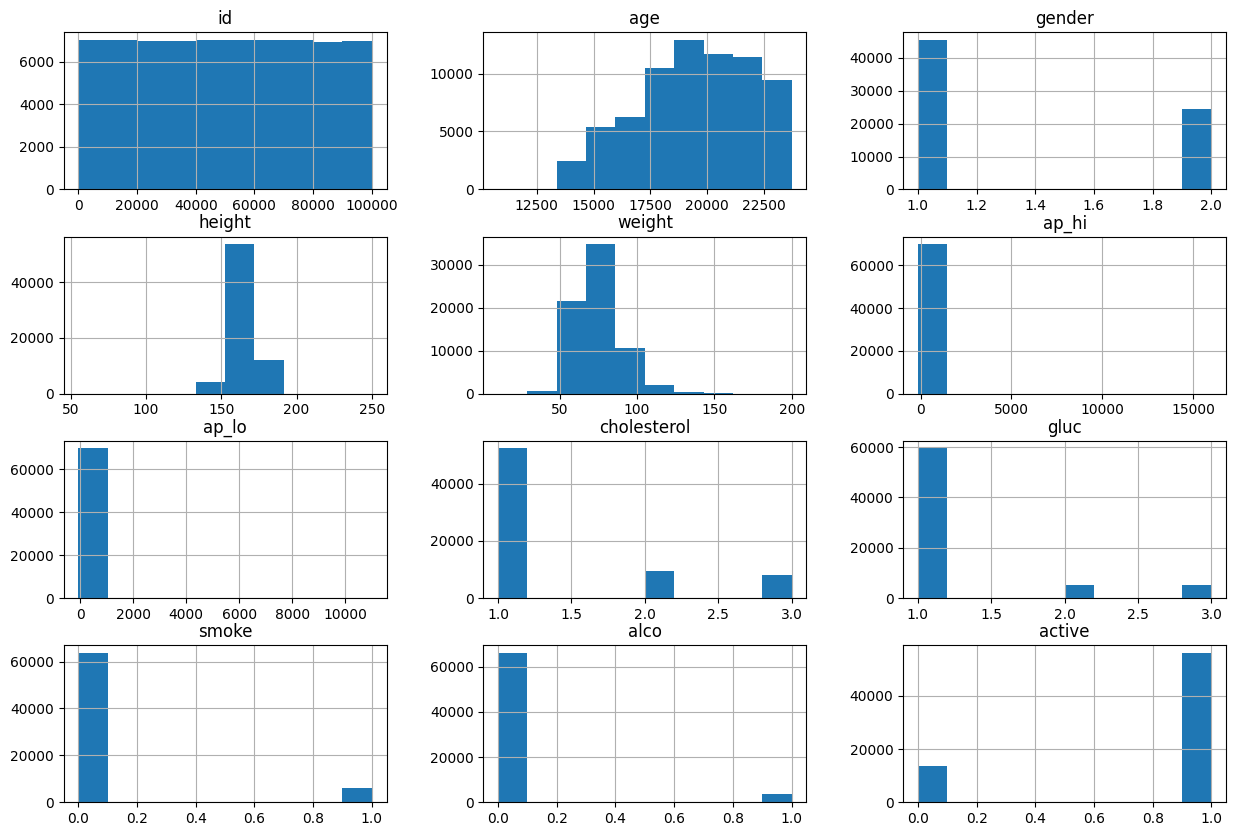

In [355]:
x=df.loc[:,df.columns!='cardio'].values[:,1:]
x1=df.loc[:,df.columns!='cardio']
y=df.loc[:,'cardio'].values
y1=df.loc[:,'cardio']
x1.hist(figsize=(15,10))
splt.show()

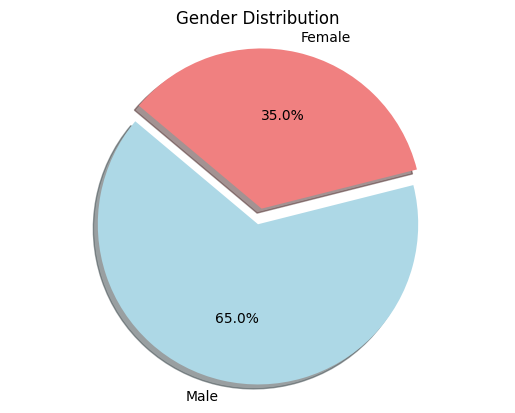

In [356]:
gender_counts = df['gender'].value_counts()
labels = ['Male', 'Female']
sizes = gender_counts.values
colors = ['lightblue', 'lightcoral']
explode = (0.1, 0)
splt.pie(sizes, explode=explode, labels=labels, colors=colors, autopct='%1.1f%%', shadow=True, startangle=140)
splt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
splt.title('Gender Distribution')
splt.show()


Distribution features with cardio

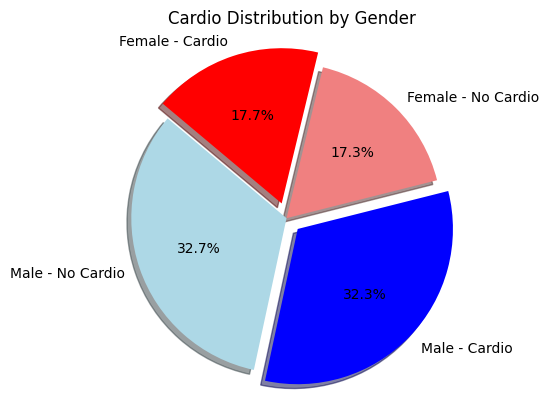

In [357]:
gender_cardio_counts = df.groupby(['gender', 'cardio']).size().unstack()
labels = ['Male - No Cardio', 'Male - Cardio', 'Female - No Cardio', 'Female - Cardio']
sizes = gender_cardio_counts.values.flatten()
colors = ['lightblue', 'blue', 'lightcoral', 'red']
explode = (0, 0.1, 0, 0.1)
splt.pie(sizes, explode=explode, labels=labels, colors=colors, autopct='%1.1f%%', shadow=True, startangle=140)
splt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
splt.title('Cardio Distribution by Gender')
splt.show()


In [358]:
gender_counts = df['gender'].value_counts()
gender_counts

gender
1    45530
2    24470
Name: count, dtype: int64

In [359]:
df['cardio'].value_counts()

cardio
0    35021
1    34979
Name: count, dtype: int64

In [360]:
non_cardio_male_count = df[(df['gender'] == 2) & (df['cardio'] == 0)].shape[0]
non_cardio_female_count = df[(df['gender'] == 1) & (df['cardio'] == 0)].shape[0]

print("Number of males without cardiovascular disease:", non_cardio_male_count)
print("Number of females without cardiovascular disease:", non_cardio_female_count)


Number of males without cardiovascular disease: 12107
Number of females without cardiovascular disease: 22914


In [361]:
cardio_male_count = df[(df['gender'] == 2) & (df['cardio'] == 1)].shape[0]
cardio_female_count = df[(df['gender'] == 1) & (df['cardio'] == 1)].shape[0]

print("Number of males with cardiovascular disease:", cardio_male_count)
print("Number of females with cardiovascular disease:", cardio_female_count)


Number of males with cardiovascular disease: 12363
Number of females with cardiovascular disease: 22616


<Axes: xlabel='gender', ylabel='count'>

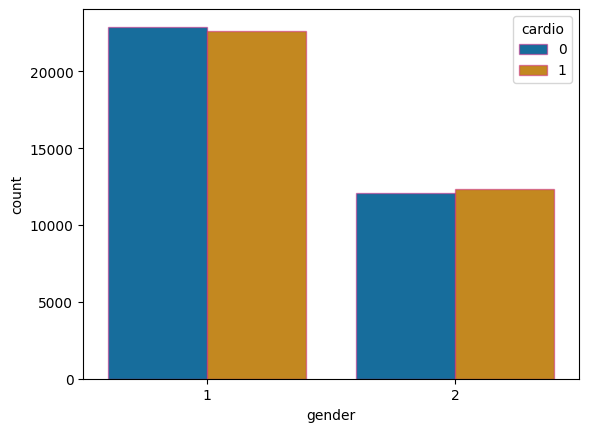

In [362]:
seaborn.countplot(x='gender',hue='cardio',data=df,palette='colorblind',edgecolor=(0.8, 0.1, 0.5, 0.5))

In [363]:
cholesterol_counts2 = df['cholesterol'].value_counts()
cholesterol_counts2

cholesterol
1    52385
2     9549
3     8066
Name: count, dtype: int64

<Figure size 1000x600 with 0 Axes>

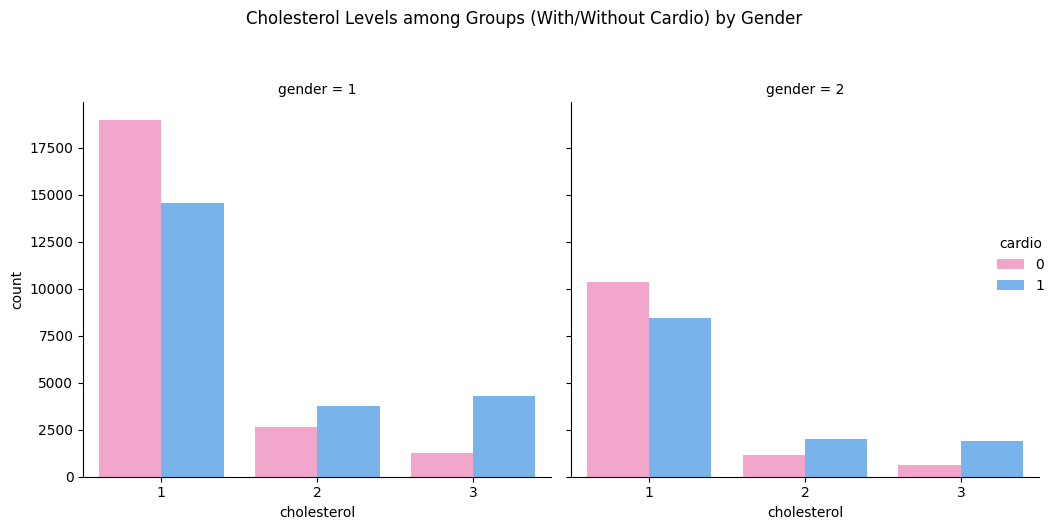

In [364]:
grouped_data = df.groupby(['cholesterol', 'cardio', 'gender']).size().reset_index(name='count')
colors = ['#ff99cc', '#66b3ff']
splt.figure(figsize=(10, 6))
seaborn.catplot(x='cholesterol', y='count', hue='cardio', col='gender', kind='bar', palette=colors, data=grouped_data)
splt.suptitle('Cholesterol Levels among Groups (With/Without Cardio) by Gender', y=1.05)
splt.xlabel('cholesterol')
splt.ylabel('Count')
splt.tight_layout()
splt.show()

In [365]:
smoke_counts2 = df['smoke'].value_counts()
smoke_counts2

smoke
0    63831
1     6169
Name: count, dtype: int64

In [366]:
alco_counts2 = df['alco'].value_counts()
alco_counts2

alco
0    66236
1     3764
Name: count, dtype: int64

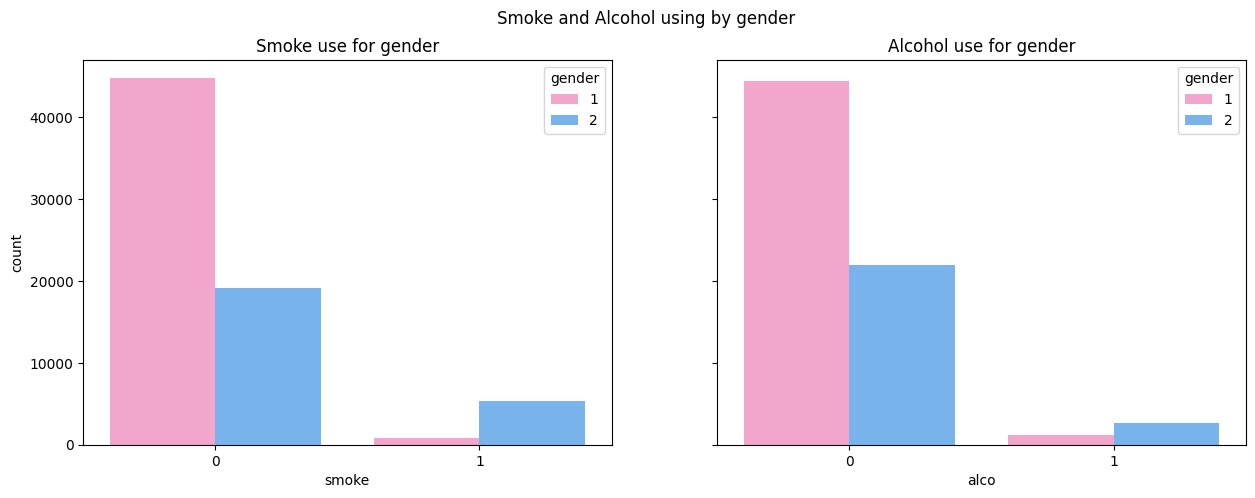

In [367]:
fig, axes = splt.subplots(1, 2, figsize=(15, 5), sharey=True)
fig.suptitle('Smoke and Alcohol using by gender')

seaborn.countplot(ax=axes[0], x=df.smoke,hue=df.gender,palette=colors)
axes[0].set_title("Smoke use for gender")


seaborn.countplot(ax=axes[1], x=df.alco,hue=df.gender,palette=colors)
axes[1].set_title("Alcohol use for gender")
splt.show()

In [368]:
df['gluc']=df['gluc']
pd.crosstab(df.gluc,df.cardio)

cardio,0,1
gluc,,
1,30894,28585
2,2112,3078
3,2015,3316


<Figure size 1000x600 with 0 Axes>

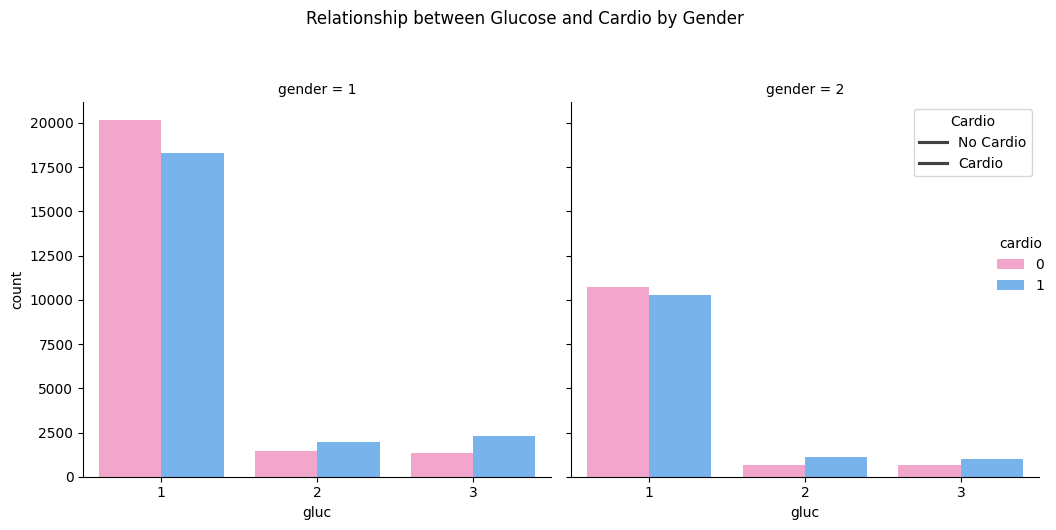

In [369]:
cross_tab = pd.crosstab([df['gluc'], df['gender']], df['cardio'])
colors = ['#ff99cc', '#66b3ff']
splt.figure(figsize=(10, 6))
seaborn.catplot(x='gluc', y='count', hue='cardio', col='gender', kind='bar', palette=colors, data=cross_tab.stack().reset_index(name='count'))
splt.suptitle('Relationship between Glucose and Cardio by Gender', y=1.05)
splt.xlabel('gluc')
splt.ylabel('Count')
splt.legend(title='Cardio', labels=['No Cardio', 'Cardio'])
splt.tight_layout()
splt.show()

In [370]:
df['active']=df['active']
pd.crosstab(df.active,df.cardio)

cardio,0,1
active,,
0,6378,7361
1,28643,27618


<Figure size 1000x600 with 0 Axes>

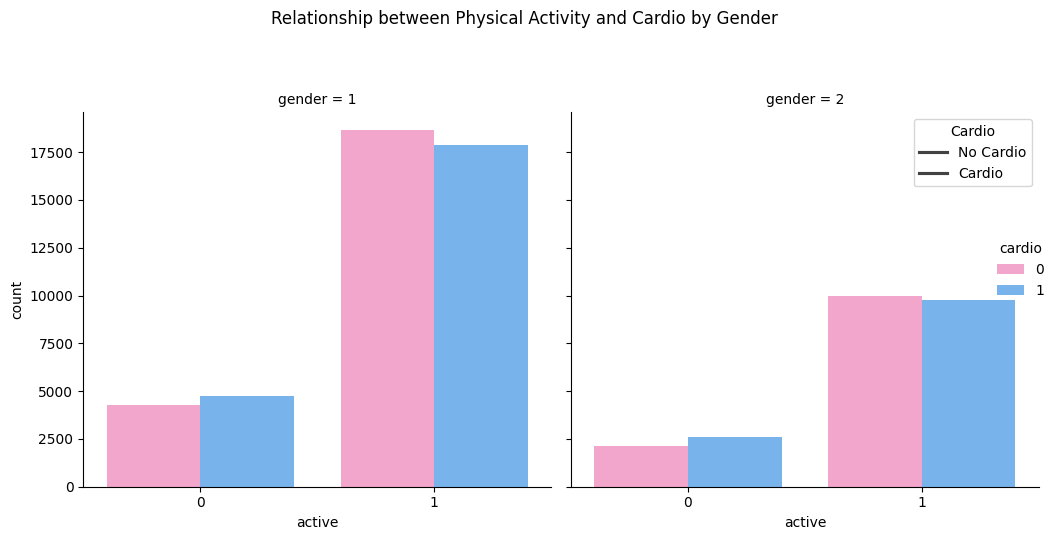

In [371]:
cross_tab = pd.crosstab([df['active'], df['gender']], df['cardio'])
colors = ['#ff99cc', '#66b3ff']
splt.figure(figsize=(10, 6))
seaborn.catplot(x='active', y='count', hue='cardio', col='gender', kind='bar', palette=colors, data=cross_tab.stack().reset_index(name='count'))
splt.suptitle('Relationship between Physical Activity and Cardio by Gender', y=1.07)
splt.xlabel('active')
splt.ylabel('Count')
splt.legend(title='Cardio', labels=['No Cardio', 'Cardio'])
splt.tight_layout()
splt.show()

In [372]:
df['height']=df['height']
pd.crosstab(df.height,df.cardio)

cardio,0,1
height,,
55,0,1
57,0,1
59,1,0
60,1,0
64,1,0
...,...,...
197,1,3
198,5,9
200,0,1


In [373]:
df['weight']=df['weight']
pd.crosstab(df.weight,df.cardio)

cardio,0,1
weight,,
10.0,0,1
11.0,0,1
21.0,0,1
22.0,1,0
23.0,1,0
...,...,...
178.0,2,1
180.0,0,4
181.0,0,1


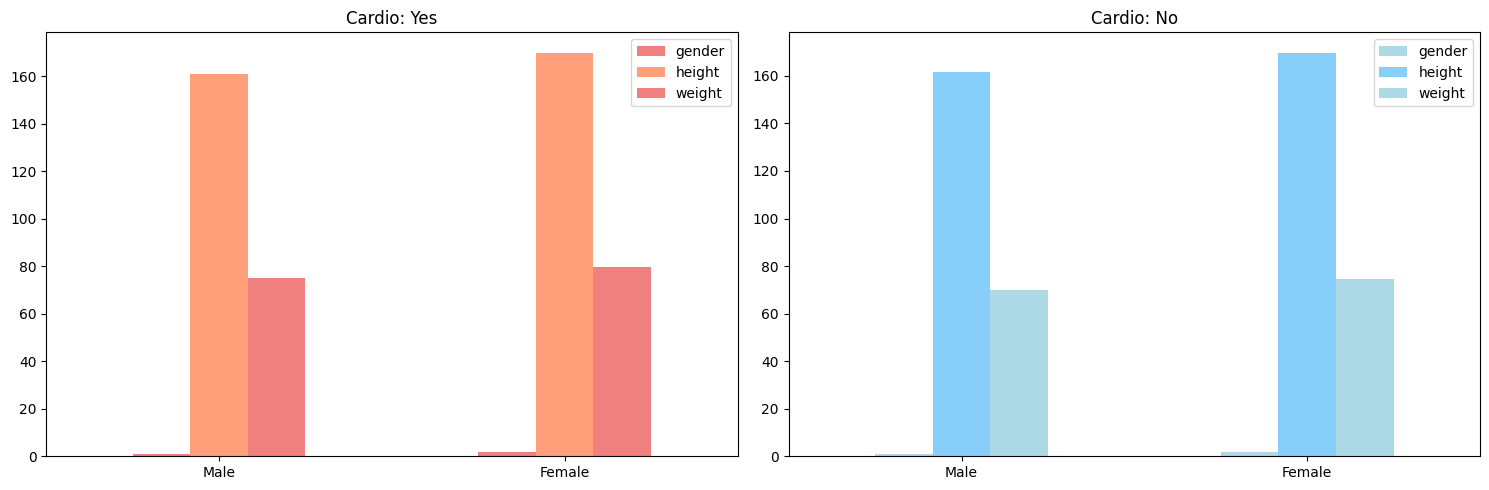

In [374]:
cardio_gender_mean = df.groupby(['cardio', 'gender']).mean()
fig, axes = splt.subplots(1, 2, figsize=(15, 5))
height_weight_cardio_yes = cardio_gender_mean.loc[(1,), ['height', 'weight']].reset_index(level='gender')
height_weight_cardio_yes.plot(kind='bar', ax=axes[0], color=['lightcoral', 'lightsalmon'])  # Changed colors for both height and weight
axes[0].set_title('Cardio: Yes')
axes[0].set_xticklabels(['Male', 'Female'], rotation=0)
height_weight_cardio_no = cardio_gender_mean.loc[(0,), ['height', 'weight']].reset_index(level='gender')
height_weight_cardio_no.plot(kind='bar', ax=axes[1], color=['lightblue', 'lightskyblue'])  # Changed colors for both height and weight
axes[1].set_title('Cardio: No')
axes[1].set_xticklabels(['Male', 'Female'], rotation=0)
splt.tight_layout()
splt.show()

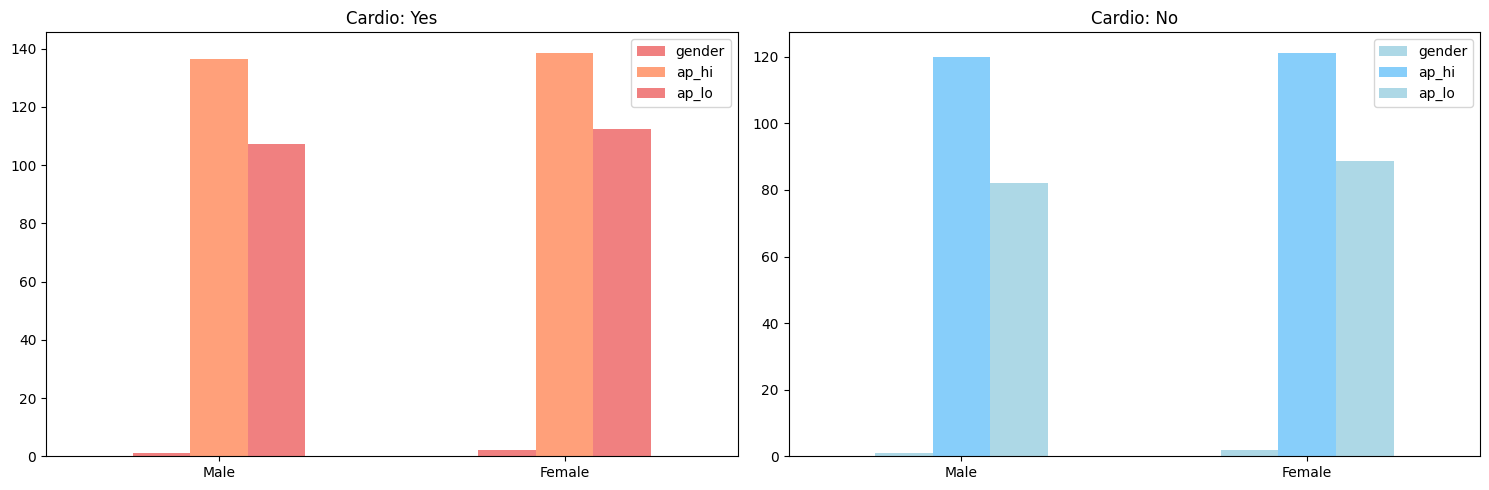

In [375]:
cardio_gender_mean = df.groupby(['cardio', 'gender']).mean()
fig, axes = splt.subplots(1, 2, figsize=(15, 5))
ap_hi_ap_lo_cardio_yes = cardio_gender_mean.loc[(1,), ['ap_hi', 'ap_lo']].reset_index(level='gender')
ap_hi_ap_lo_cardio_yes.plot(kind='bar', ax=axes[0], color=['lightcoral', 'lightsalmon'])
axes[0].set_title('Cardio: Yes')
axes[0].set_xticklabels(['Male', 'Female'], rotation=0)
ap_hi_ap_lo_cardio_no = cardio_gender_mean.loc[(0,), ['ap_hi', 'ap_lo']].reset_index(level='gender')
ap_hi_ap_lo_cardio_no.plot(kind='bar', ax=axes[1], color=['lightblue', 'lightskyblue'])
axes[1].set_title('Cardio: No')
axes[1].set_xticklabels(['Male', 'Female'], rotation=0)
splt.tight_layout()
splt.show()


In [376]:
df = df.drop('id', axis=1)

Removing Outliers

In [377]:
df.drop(df[(df['height'] > df['height'].quantile(0.975)) | (df['height'] < df['height'].quantile(0.025))].index,inplace=True)
df.drop(df[(df['weight'] > df['weight'].quantile(0.975)) | (df['weight'] < df['weight'].quantile(0.025))].index,inplace=True)
df.drop(df[(df['ap_hi'] > df['ap_hi'].quantile(0.975)) | (df['ap_hi'] < df['ap_hi'].quantile(0.025))].index,inplace=True)
df.drop(df[(df['ap_lo'] > df['ap_lo'].quantile(0.975)) | (df['ap_lo'] < df['ap_lo'].quantile(0.025))].index,inplace=True)
len(df)

60142

In [378]:
df[df['ap_lo']> df['ap_hi']].shape[0]

0

<Axes: xlabel='age', ylabel='count'>

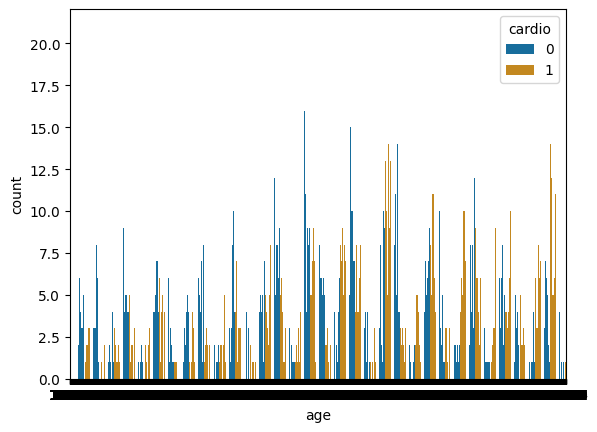

In [379]:
seaborn.countplot(x='age',hue='cardio',data=df,palette='colorblind',color='black')

Converting age from days to years

In [380]:
df['age'] = (df['age'] / 365).round().astype('int')

print(df)

       age  gender  height  weight  ap_hi  ap_lo  cholesterol  gluc  smoke  \
0       50       2     168    62.0    110     80            1     1      0   
1       55       1     156    85.0    140     90            3     1      0   
2       52       1     165    64.0    130     70            3     1      0   
3       48       2     169    82.0    150    100            1     1      0   
4       48       1     156    56.0    100     60            1     1      0   
...    ...     ...     ...     ...    ...    ...          ...   ...    ...   
69993   54       1     172    70.0    130     90            1     1      0   
69994   58       1     165    80.0    150     80            1     1      0   
69995   53       2     168    76.0    120     80            1     1      1   
69998   61       1     163    72.0    135     80            1     2      0   
69999   56       1     170    72.0    120     80            2     1      0   

       alco  active  cardio  
0         0       1       0  
1  

<Axes: xlabel='age', ylabel='count'>

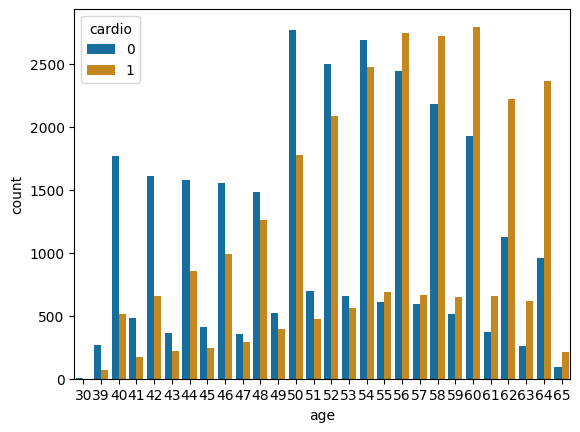

In [381]:
seaborn.countplot(x='age',hue='cardio',data=df,palette='colorblind',color='black')

Categorizing features

In [382]:
age_edges = [30, 35, 40, 45, 50, 55, 60, 65]
age_labels = [0, 1, 2, 3, 4, 5, 6]
df['age_group'] = pd.cut(df['age'], bins=7, labels=range(7), include_lowest=True,right=True)
df.head()

,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,age_group
0,50,2,168,62.0,110,80,1,1,0,0,1,0,3
1,55,1,156,85.0,140,90,3,1,0,0,1,1,4
2,52,1,165,64.0,130,70,3,1,0,0,0,1,4
3,48,2,169,82.0,150,100,1,1,0,0,1,1,3
4,48,1,156,56.0,100,60,1,1,0,0,0,0,3


Attribute Combination

In [383]:
df['bmi'] = df['weight']/((df['height']/100)**2)
df.head()

bmiMin = int(df['bmi'].min())
bmiMax = int(df['bmi'].max())

print(bmiMin, bmiMax)

df['bmi'] = pd.cut(df['bmi'], bins=6, labels=range(6), right=True, include_lowest=True)

df.head()


df["bmi"].value_counts(normalize=True)

16 46


bmi
1    0.461325
2    0.330202
3    0.133068
0    0.038193
4    0.033554
5    0.003658
Name: proportion, dtype: float64

In [384]:
df['map'] = ((2* df['ap_lo']) + df['ap_hi']) / 3

mapMin = int(df['map'].min())
mapMax = int(df['map'].max())

print(mapMin, mapMax)

df['map'] = pd.cut(df['map'], bins=6, labels=range(6), right=True, include_lowest=True)

df.head()
df["map"].value_counts(normalize=True)

73 121


map
2    0.505287
4    0.135463
1    0.131040
3    0.120631
5    0.062818
0    0.044761
Name: proportion, dtype: float64

In [385]:
df['map'] = ((2* df['ap_lo']) + df['ap_hi']) / 3

mapMin = int(df['map'].min())
mapMax = int(df['map'].max())

print(mapMin, mapMax)

df['map'] = pd.cut(df['map'], bins=6, labels=range(6), right=True, include_lowest=True)

df.head()

73 121


,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,age_group,bmi,map
0,50,2,168,62.0,110,80,1,1,0,0,1,0,3,1,2
1,55,1,156,85.0,140,90,3,1,0,0,1,1,4,3,4
2,52,1,165,64.0,130,70,3,1,0,0,0,1,4,1,2
3,48,2,169,82.0,150,100,1,1,0,0,1,1,3,2,5
4,48,1,156,56.0,100,60,1,1,0,0,0,0,3,1,0


Print Null rows

In [386]:
null_rows = df[df.isnull().any(axis=1)]
print("Rows with null values:")
print(null_rows)

Rows with null values:
Empty DataFrame
Columns: [age, gender, height, weight, ap_hi, ap_lo, cholesterol, gluc, smoke, alco, active, cardio, age_group, bmi, map]
Index: []


Drop features

In [387]:
df_og=df

df=df.drop(['height','weight','ap_hi','ap_lo','age'],axis=1)

df.head()

,gender,cholesterol,gluc,smoke,alco,active,cardio,age_group,bmi,map
0,2,1,1,0,0,1,0,3,1,2
1,1,3,1,0,0,1,1,4,3,4
2,1,3,1,0,0,0,1,4,1,2
3,2,1,1,0,0,1,1,3,2,5
4,1,1,1,0,0,0,0,3,1,0


Label Encoder

In [388]:
from sklearn import preprocessing

In [389]:
le = preprocessing.LabelEncoder()
df = df.apply(le.fit_transform)
df.describe()

,gender,cholesterol,gluc,smoke,alco,active,cardio,age_group,bmi,map
count,60142.000000,60142.000000,60142.000000,60142.000000,60142.000000,60142.000000,60142.000000,60142.000000,60142.000000,60142.000000
mean,0.347311,0.350953,0.220229,0.085631,0.051877,0.803648,0.488228,4.042233,1.673440,2.359449
std,0.476120,0.670076,0.567607,0.279820,0.221781,0.397241,0.499866,1.377070,0.898707,1.186906
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,3.000000,1.000000,2.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,4.000000,2.000000,2.000000
75%,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,5.000000,2.000000,3.000000
max,1.000000,2.000000,2.000000,1.000000,1.000000,1.000000,1.000000,6.000000,5.000000,5.000000


Clustering

In [390]:
cost = []
num_clusters = range(1, 6)  # 1 to 5
for i in list(num_clusters):
    kmode = KModes(n_clusters=i, init="Huang", n_init=5, verbose=0, random_state=1)
    kmode.fit_predict(df)
    cost.append(kmode.cost_)

Clusters graph

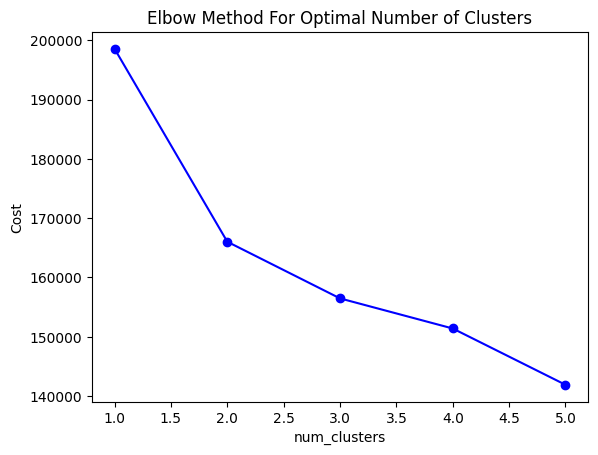

In [391]:
splt.plot(num_clusters, cost, 'bo-')
splt.xlabel('num_clusters')
splt.ylabel('Cost')
splt.title('Elbow Method For Optimal Number of Clusters')
splt.show()

Building KModes model

In [392]:
km = KModes(n_clusters=2, init = "Huang", n_init = 5,random_state=1)
clusters = km.fit_predict(df)
clusters

array([1, 0, 1, ..., 1, 0, 1], dtype=uint16)

In [393]:
df.insert(0,"clusters",clusters,True)

df.head()

,clusters,gender,cholesterol,gluc,smoke,alco,active,cardio,age_group,bmi,map
0,1,1,0,0,0,0,1,0,3,1,2
1,0,0,2,0,0,0,1,1,4,3,4
2,1,0,2,0,0,0,0,1,4,1,2
3,0,1,0,0,0,0,1,1,3,2,5
4,1,0,0,0,0,0,0,0,3,1,0


Correlation Matrix

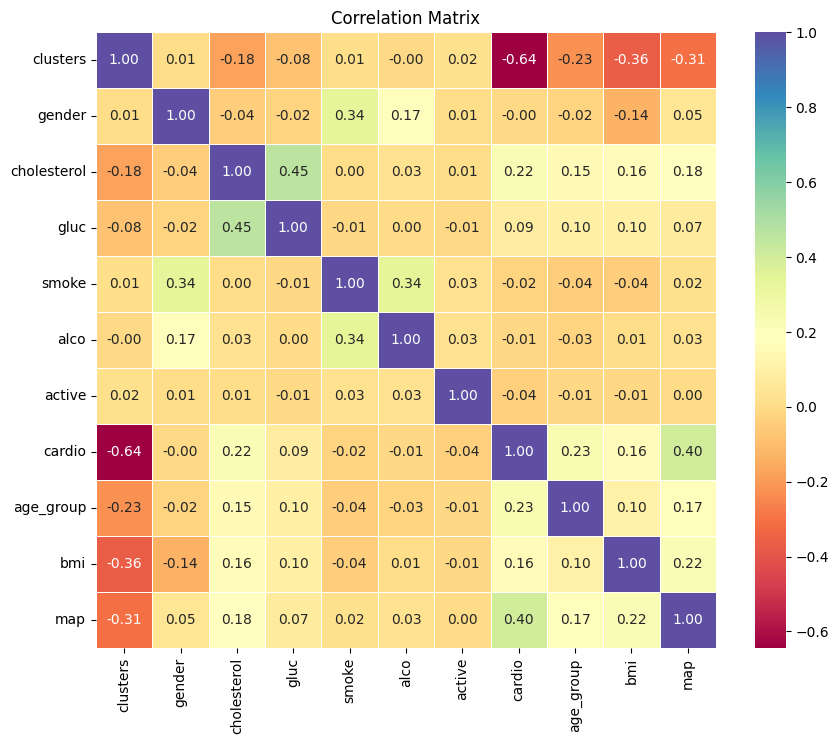

In [394]:
splt.figure(figsize=(10, 8))
seaborn.heatmap(df.corr(), annot=True, cmap='Spectral', fmt=".2f", linewidths=.5)
splt.title('Correlation Matrix')
splt.show()

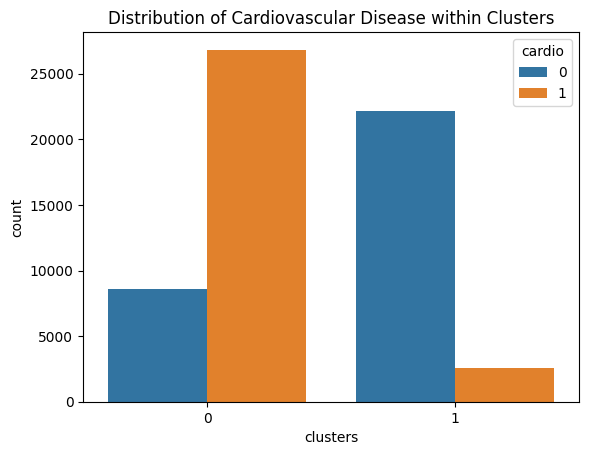

In [395]:
seaborn.countplot(x='clusters', hue='cardio', data=df)
splt.title('Distribution of Cardiovascular Disease within Clusters')
splt.show()

In [396]:
x = df.drop(['cardio','gender','alco'], axis=1)
y = df['cardio']

x.head()

,clusters,cholesterol,gluc,smoke,active,age_group,bmi,map
0,1,0,0,0,1,3,1,2
1,0,2,0,0,1,4,3,4
2,1,2,0,0,0,4,1,2
3,0,0,0,0,1,3,2,5
4,1,0,0,0,0,3,1,0


Split Data

In [397]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.20,random_state=1)

Random Forest¶

In [398]:
from sklearn.ensemble import RandomForestClassifier


In [399]:
rfModel = RandomForestClassifier(random_state=1)
rfModel.fit(x_train, y_train)
rf_pred = rfModel.predict(x_test)
rf_accuracy = metrics.accuracy_score(y_test, rf_pred)*100


In [400]:
rf_train_pred = rfModel.predict(x_train)
rf_train_accuracy = metrics.accuracy_score(y_train, rf_train_pred) * 100
print(f"Training Accuracy: {rf_train_accuracy:.2f}")


Training Accuracy: 88.29


In [401]:
from sklearn.model_selection import GridSearchCV

rf_best_params = {
    'n_estimators': [100],
    'max_depth': [10],
    'min_samples_split': [10],
    'min_samples_leaf': [1],
    'max_features': [None],
}

rf_gridsearch = GridSearchCV(estimator=rfModel,param_grid=rf_best_params, cv=5, scoring='accuracy',n_jobs=-1)

rf_gridsearch.fit(x_train, y_train)

GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=1), n_jobs=-1,
             param_grid={'max_depth': [10], 'max_features': [None],
                         'min_samples_leaf': [1], 'min_samples_split': [10],
                         'n_estimators': [100]},
             scoring='accuracy')

In [402]:
best_params = rf_gridsearch.best_params_
best_estimator = rf_gridsearch.best_estimator_

print(f"Best Parameters : {best_params}")
print(f"Best Estimator  : {best_estimator}")

Best Parameters : {'max_depth': 10, 'max_features': None, 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 100}
Best Estimator  : RandomForestClassifier(max_depth=10, max_features=None, min_samples_split=10,
                       random_state=1)


In [403]:
rf_pred_CV = best_estimator.predict(x_test)

In [404]:
rf_accuracy_cv = metrics.accuracy_score(y_test, rf_pred_CV)*100
print(f"Best Accuracy: {rf_accuracy_cv:.2f}")

Best Accuracy: 87.82


In [405]:
classification_report_str = classification_report(y_test, rf_pred_CV, digits=4)

print("Classification Report for RF with CV:\n", classification_report_str)

Classification Report for RF with CV:
               precision    recall  f1-score   support

           0     0.8837    0.8804    0.8820      6220
           1     0.8724    0.8759    0.8742      5809

    accuracy                         0.8782     12029
   macro avg     0.8780    0.8781    0.8781     12029
weighted avg     0.8782    0.8782    0.8782     12029



Text(0.5, 427.9555555555555, 'Predicted label')

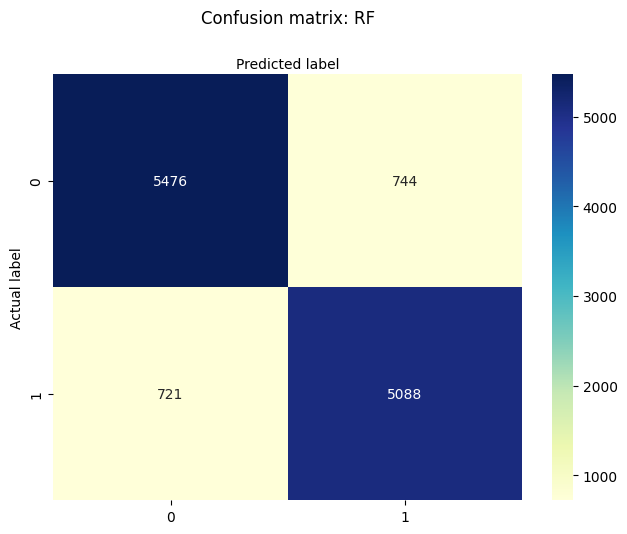

In [406]:
cnf_matrix = metrics.confusion_matrix(y_test, rf_pred_CV)
cnf_matrix

class_names=[0,1] # name  of classes
fig, ax = splt.subplots()
tick_marks = np.arange(len(class_names))
splt.xticks(tick_marks, class_names)
splt.yticks(tick_marks, class_names)
# create heatmap
seaborn.heatmap(pd.DataFrame(cnf_matrix), annot=True, cmap="YlGnBu" ,fmt='g')
ax.xaxis.set_label_position("top")
splt.tight_layout()
splt.title('Confusion matrix: RF', y=1.1)
splt.ylabel('Actual label')
splt.xlabel('Predicted label')

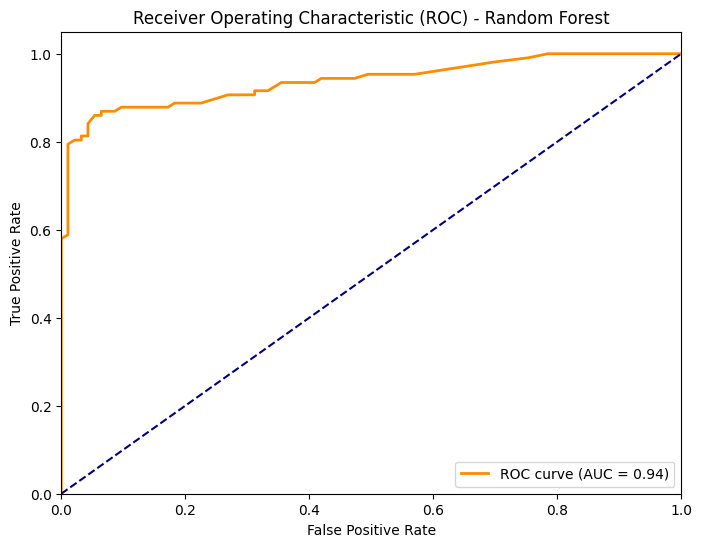

In [407]:

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, auc
from sklearn.ensemble import RandomForestClassifier
x, y = make_classification(n_samples=1000, n_features=20, n_classes=2, random_state=42)
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
rf_classifier = RandomForestClassifier(random_state=42)
rf_classifier.fit(x_train, y_train)
y_score = rf_classifier.predict_proba(x_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_score)
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) - Random Forest')
plt.legend(loc="lower right")
plt.show()


In [408]:
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
x, y = make_classification(n_samples=1000, n_features=20, n_classes=2, random_state=42)
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

model_nn = tf.keras.Sequential([
    tf.keras.layers.Dense(64, activation='relu', input_shape=(20,)),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

model_nn.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])
early_stopping_nn = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3)
model_nn.fit(x_train, y_train, epochs=50, batch_size=32, validation_data=(x_test, y_test), callbacks=[early_stopping_nn])
model_rf = RandomForestClassifier(n_estimators=100, random_state=42)
model_rf.fit(x_train, y_train)
y_pred_rf_train = model_rf.predict(x_train)
y_pred_rf_test = model_rf.predict(x_test)

Epoch 1/50
25/25 [==============================] - 2s 16ms/step - loss: 0.5718 - accuracy: 0.7525 - val_loss: 0.5063 - val_accuracy: 0.8100
Epoch 2/50
25/25 [==============================] - 0s 6ms/step - loss: 0.4059 - accuracy: 0.8687 - val_loss: 0.4116 - val_accuracy: 0.8300
Epoch 3/50
25/25 [==============================] - 0s 6ms/step - loss: 0.3276 - accuracy: 0.8800 - val_loss: 0.3731 - val_accuracy: 0.8450
Epoch 4/50
25/25 [==============================] - 0s 5ms/step - loss: 0.2930 - accuracy: 0.8875 - val_loss: 0.3682 - val_accuracy: 0.8550
Epoch 5/50
25/25 [==============================] - 0s 5ms/step - loss: 0.2763 - accuracy: 0.8875 - val_loss: 0.3616 - val_accuracy: 0.8500
Epoch 6/50
25/25 [==============================] - 0s 7ms/step - loss: 0.2656 - accuracy: 0.8975 - val_loss: 0.3666 - val_accuracy: 0.8450
Epoch 7/50
25/25 [==============================] - 0s 6ms/step - loss: 0.2549 - accuracy: 0.9075 - val_loss: 0.3611 - val_accuracy: 0.8400
Epoch 8/50
25/25 [=

Multi-layer Perceptron

In [409]:
from sklearn.neural_network import MLPClassifier


In [410]:
mlpModel = MLPClassifier(random_state=1)
mlpModel.fit(x_train, y_train)
mlp_pred = mlpModel.predict(x_test)
mlp_accuracy = metrics.accuracy_score(y_test, mlp_pred)*100

/usr/local/lib/python3.10/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:686: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


In [411]:
from sklearn.metrics import accuracy_score

mlpModel.fit(x_train, y_train)

mlp_pred_train = mlpModel.predict(x_train)

mlp_training_accuracy = accuracy_score(y_train, mlp_pred_train)

print(f"MLP Training Accuracy: {mlp_training_accuracy:.2f}")

MLP Training Accuracy: 0.98


/usr/local/lib/python3.10/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:686: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


In [412]:
from sklearn.model_selection import GridSearchCV

In [413]:
mlp_best_params = {
    'activation': ['tanh'],
    'alpha': [0.01],
    'hidden_layer_sizes': [(50, 50)],
    'max_iter': [300],
    'solver': ['adam'],
}


mlp_gridsearch = GridSearchCV(estimator=mlpModel, param_grid=mlp_best_params, cv=5, scoring='accuracy', n_jobs=-1)

mlp_gridsearch.fit(x_train, y_train)

/usr/local/lib/python3.10/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:686: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(


GridSearchCV(cv=5, estimator=MLPClassifier(random_state=1), n_jobs=-1,
             param_grid={'activation': ['tanh'], 'alpha': [0.01],
                         'hidden_layer_sizes': [(50, 50)], 'max_iter': [300],
                         'solver': ['adam']},
             scoring='accuracy')

In [414]:
mlp_best_estimator = mlp_gridsearch.best_estimator_

print(f"Best Parameters : {mlp_best_params}")
print(f"Best Estimator  : {mlp_best_estimator}")

Best Parameters : {'activation': ['tanh'], 'alpha': [0.01], 'hidden_layer_sizes': [(50, 50)], 'max_iter': [300], 'solver': ['adam']}
Best Estimator  : MLPClassifier(activation='tanh', alpha=0.01, hidden_layer_sizes=(50, 50),
              max_iter=300, random_state=1)


In [415]:
mlp_pred_CV = mlp_best_estimator.predict(x_test)

In [416]:
mlp_accuracy_cv = metrics.accuracy_score(y_test, mlp_pred_CV)*100
print(f"Best Accuracy: {mlp_accuracy_cv:.2f}")

Best Accuracy: 82.50


Text(0.5, 427.9555555555555, 'Predicted label')

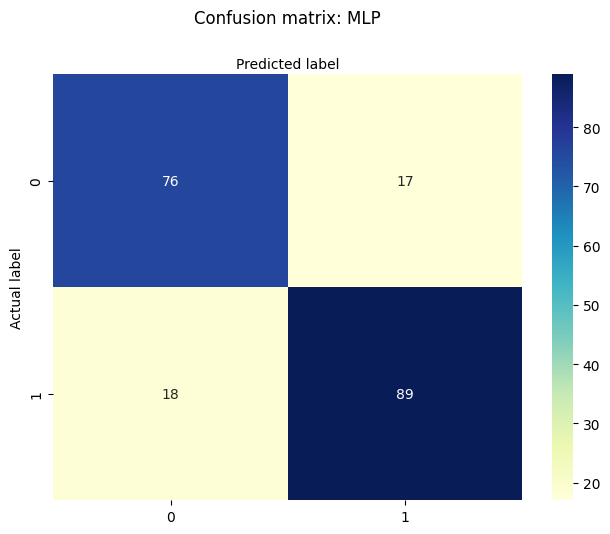

In [417]:
cnf_matrix = metrics.confusion_matrix(y_test, mlp_pred_CV)
cnf_matrix

class_names=[0,1]
fig, ax = splt.subplots()
tick_marks = np.arange(len(class_names))
splt.xticks(tick_marks, class_names)
splt.yticks(tick_marks, class_names)
seaborn.heatmap(pd.DataFrame(cnf_matrix), annot=True, cmap="YlGnBu" ,fmt='g')
ax.xaxis.set_label_position("top")
splt.tight_layout()
splt.title('Confusion matrix: MLP', y=1.1)
splt.ylabel('Actual label')
splt.xlabel('Predicted label')

/usr/local/lib/python3.10/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:686: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


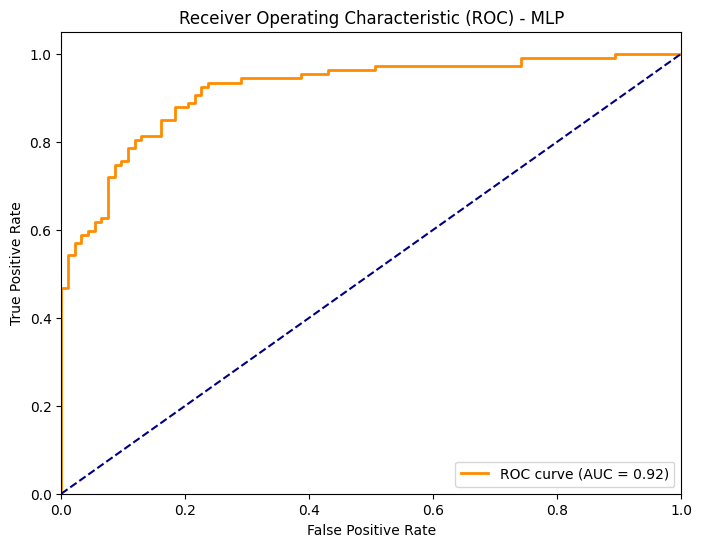

In [418]:
from sklearn.metrics import roc_curve, auc
from sklearn.neural_network import MLPClassifier
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
x, y = make_classification(n_samples=1000, n_features=20, n_classes=2, random_state=42)
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
mlp_classifier = MLPClassifier(random_state=42)
mlp_classifier.fit(x_train, y_train)
y_score = mlp_classifier.predict_proba(x_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_score)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) - MLP')
plt.legend(loc="lower right")
plt.show()


In [419]:
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
x, y = make_classification(n_samples=1000, n_features=20, n_classes=2, random_state=42)
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
model = tf.keras.Sequential([
    tf.keras.layers.Dense(64, activation='relu', input_shape=(20,)),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])
early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3)

model.fit(x_train, y_train, epochs=50, batch_size=32, validation_data=(x_test, y_test), callbacks=[early_stop])


Epoch 1/50
25/25 [==============================] - 1s 11ms/step - loss: 0.5295 - accuracy: 0.7900 - val_loss: 0.4727 - val_accuracy: 0.8150
Epoch 2/50
25/25 [==============================] - 0s 4ms/step - loss: 0.3875 - accuracy: 0.8512 - val_loss: 0.4105 - val_accuracy: 0.8300
Epoch 3/50
25/25 [==============================] - 0s 3ms/step - loss: 0.3258 - accuracy: 0.8750 - val_loss: 0.3807 - val_accuracy: 0.8450
Epoch 4/50
25/25 [==============================] - 0s 5ms/step - loss: 0.2995 - accuracy: 0.8813 - val_loss: 0.3787 - val_accuracy: 0.8550
Epoch 5/50
25/25 [==============================] - 0s 3ms/step - loss: 0.2823 - accuracy: 0.8888 - val_loss: 0.3766 - val_accuracy: 0.8500
Epoch 6/50
25/25 [==============================] - 0s 4ms/step - loss: 0.2719 - accuracy: 0.8913 - val_loss: 0.3718 - val_accuracy: 0.8500
Epoch 7/50
25/25 [==============================] - 0s 5ms/step - loss: 0.2601 - accuracy: 0.8938 - val_loss: 0.3661 - val_accuracy: 0.8450
Epoch 8/50
25/25 [=

In [420]:
classification_report_str = classification_report(y_test, mlp_pred_CV, digits=4)

print("Classification Report for MLP with CV:\n", classification_report_str)

Classification Report for MLP with CV:
               precision    recall  f1-score   support

           0     0.8085    0.8172    0.8128        93
           1     0.8396    0.8318    0.8357       107

    accuracy                         0.8250       200
   macro avg     0.8241    0.8245    0.8243       200
weighted avg     0.8252    0.8250    0.8251       200



Support Vector Machine

In [421]:
from sklearn.svm import SVC


In [422]:
svmModel = SVC(random_state=1)

svmModel.fit(x_train, y_train)

svm_pred = mlpModel.predict(x_test)

svm_accuracy = metrics.accuracy_score(y_test, svm_pred)*100


In [423]:
from sklearn.metrics import accuracy_score

svmModel.fit(x_train, y_train)

svm_pred_train = svmModel.predict(x_train)

svm_training_accuracy = accuracy_score(y_train, svm_pred_train)

print(f"  SVC Training Accuracy: {svm_training_accuracy:.2f}")

  SVC Training Accuracy: 0.93


In [424]:
svm_param_grid = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf', 'poly'],
    'gamma': ['scale', 'auto'],
}

svm_best_params = {
    'C': [10],
    'kernel': ['rbf'],
    'gamma': ['auto'],
}


svm_gridsearch = GridSearchCV(estimator=svmModel, param_grid=svm_best_params, cv=5, scoring='accuracy', n_jobs=-1)

svm_gridsearch.fit(x_train, y_train)

GridSearchCV(cv=5, estimator=SVC(random_state=1), n_jobs=-1,
             param_grid={'C': [10], 'gamma': ['auto'], 'kernel': ['rbf']},
             scoring='accuracy')

In [425]:
svm_best_params = svm_gridsearch.best_params_
svm_best_estimator = svm_gridsearch.best_estimator_

print(f"Best Parameters : {svm_best_params}")
print(f"Best Estimator  : {svm_best_estimator}")

Best Parameters : {'C': 10, 'gamma': 'auto', 'kernel': 'rbf'}
Best Estimator  : SVC(C=10, gamma='auto', random_state=1)


In [426]:
svm_pred_CV = svm_best_estimator.predict(x_test)

In [427]:
svm_accuracy_cv = metrics.accuracy_score(y_test, svm_pred_CV)*100
print(f"Best Accuracy: {svm_accuracy_cv:.2f}")

Best Accuracy: 85.50


Text(0.5, 427.9555555555555, 'Predicted label')

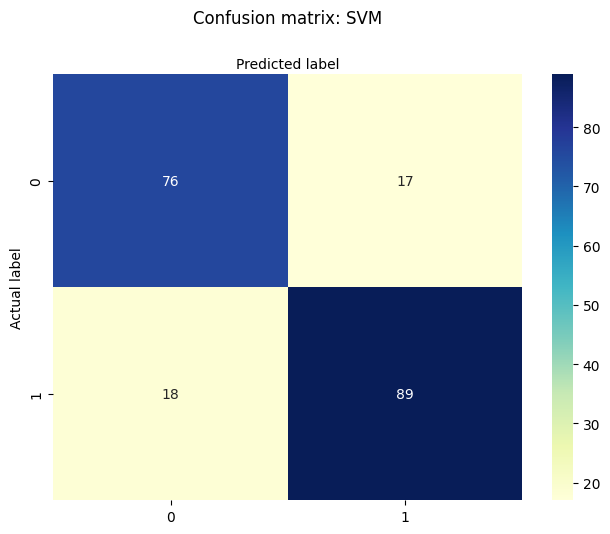

In [428]:
cnf_matrix = metrics.confusion_matrix(y_test, mlp_pred_CV)
cnf_matrix

class_names=[0,1]
fig, ax = splt.subplots()
tick_marks = np.arange(len(class_names))
splt.xticks(tick_marks, class_names)
splt.yticks(tick_marks, class_names)
seaborn.heatmap(pd.DataFrame(cnf_matrix), annot=True, cmap="YlGnBu" ,fmt='g')
ax.xaxis.set_label_position("top")
splt.tight_layout()
splt.title('Confusion matrix: SVM', y=1.1)
splt.ylabel('Actual label')
splt.xlabel('Predicted label')

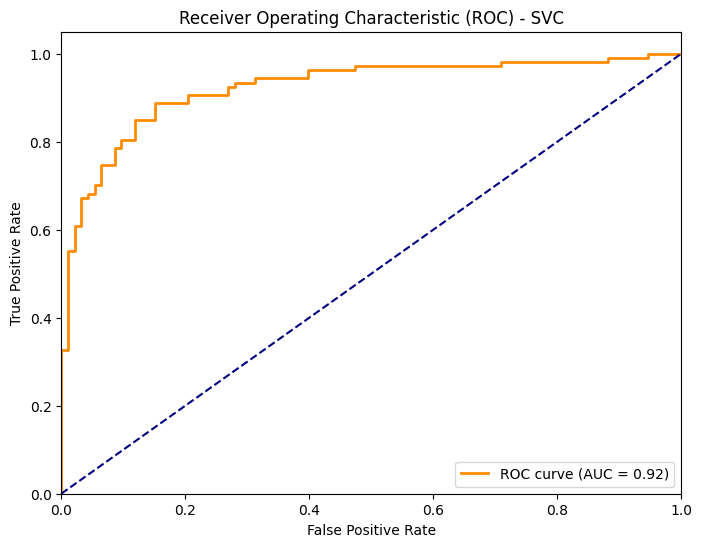

In [429]:
from sklearn.metrics import roc_curve, auc
from sklearn.svm import SVC
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
x, y = make_classification(n_samples=1000, n_features=20, n_classes=2, random_state=42)
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

svc_classifier = SVC(probability=True, random_state=42)
svc_classifier.fit(x_train, y_train)
y_score = svc_classifier.predict_proba(x_test)[:, 1]

fpr, tpr, _ = roc_curve(y_test, y_score)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) - SVC')
plt.legend(loc="lower right")
plt.show()


In [430]:
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
x, y = make_classification(n_samples=1000, n_features=20, n_classes=2, random_state=42)
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

model_nn = tf.keras.Sequential([
    tf.keras.layers.Dense(64, activation='relu', input_shape=(20,)),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

model_nn.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])
early_stopping_nn = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3)
model_nn.fit(x_train, y_train, epochs=50, batch_size=32, validation_data=(x_test, y_test), callbacks=[early_stopping_nn])
model_svc = SVC(random_state=42)
model_svc.fit(x_train, y_train)
y_pred_svc_train = model_svc.predict(x_train)
y_pred_svc_test = model_svc.predict(x_test)




Epoch 1/50
25/25 [==============================] - 2s 19ms/step - loss: 0.5863 - accuracy: 0.7225 - val_loss: 0.4970 - val_accuracy: 0.8000
Epoch 2/50
25/25 [==============================] - 0s 6ms/step - loss: 0.4156 - accuracy: 0.8512 - val_loss: 0.4090 - val_accuracy: 0.8350
Epoch 3/50
25/25 [==============================] - 0s 8ms/step - loss: 0.3400 - accuracy: 0.8637 - val_loss: 0.3768 - val_accuracy: 0.8500
Epoch 4/50
25/25 [==============================] - 0s 6ms/step - loss: 0.3045 - accuracy: 0.8800 - val_loss: 0.3594 - val_accuracy: 0.8600
Epoch 5/50
25/25 [==============================] - 0s 7ms/step - loss: 0.2855 - accuracy: 0.8850 - val_loss: 0.3563 - val_accuracy: 0.8550
Epoch 6/50
25/25 [==============================] - 0s 10ms/step - loss: 0.2722 - accuracy: 0.8963 - val_loss: 0.3614 - val_accuracy: 0.8650
Epoch 7/50
25/25 [==============================] - 0s 10ms/step - loss: 0.2596 - accuracy: 0.9000 - val_loss: 0.3586 - val_accuracy: 0.8500
Epoch 8/50
25/25 

In [431]:
classification_report_str = classification_report(y_test, svm_pred_CV, digits=4)

print("Classification Report for SVM with CV:\n", classification_report_str)

Classification Report for SVM with CV:
               precision    recall  f1-score   support

           0     0.8265    0.8710    0.8482        93
           1     0.8824    0.8411    0.8612       107

    accuracy                         0.8550       200
   macro avg     0.8544    0.8560    0.8547       200
weighted avg     0.8564    0.8550    0.8552       200



K-Nearest Neighbors

In [432]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn import metrics
knnModel = KNeighborsClassifier()
knnModel.fit(x_train, y_train)
knn_pred = knnModel.predict(x_test)
knn_accuracy = metrics.accuracy_score(y_test, knn_pred) * 100





In [433]:
from sklearn.metrics import accuracy_score
knn_train_pred = knnModel.predict(x_train)
knn_train_accuracy = accuracy_score(y_train, knn_train_pred) * 100
print(f"KNN training accuracy: {knn_train_accuracy:.2f}")


KNN training accuracy: 88.50


In [434]:
knn_param_grid = {
    'n_neighbors': [3, 5, 7],
    'weights': ['uniform', 'distance'],
    'algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute'],
    'p': [1, 2]
}
knn_best_params = {
    'n_neighbors': [5],
    'weights': ['uniform'],
    'algorithm': ['auto'],
    'p': [2]
}
knnModel = KNeighborsClassifier()
knn_gridsearch = GridSearchCV(estimator=knnModel, param_grid=knn_best_params, cv=5, scoring='accuracy', n_jobs=-1)
knn_gridsearch.fit(x_train, y_train)





GridSearchCV(cv=5, estimator=KNeighborsClassifier(), n_jobs=-1,
             param_grid={'algorithm': ['auto'], 'n_neighbors': [5], 'p': [2],
                         'weights': ['uniform']},
             scoring='accuracy')

In [435]:
knn_best_params = knn_gridsearch.best_params_
knn_best_estimator = knn_gridsearch.best_estimator_

print(f"Best Parameters : {knn_best_params}")
print(f"Best Estimator  : {knn_best_estimator}")

Best Parameters : {'algorithm': 'auto', 'n_neighbors': 5, 'p': 2, 'weights': 'uniform'}
Best Estimator  : KNeighborsClassifier()


In [436]:
knn_pred_CV = knn_best_estimator.predict(x_test)

In [437]:
knn_accuracy_cv = metrics.accuracy_score(y_test, knn_pred_CV)*100
print(f"Best Accuracy: {knn_accuracy_cv:.2f}")

Best Accuracy: 81.00


Text(0.5, 427.9555555555555, 'Predicted label')

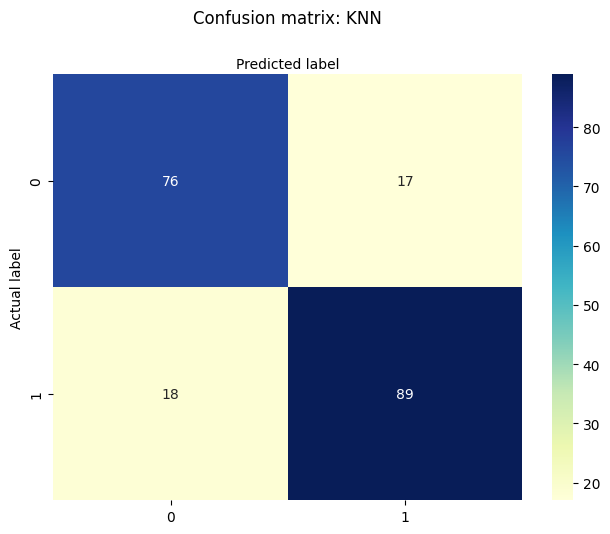

In [438]:
cnf_matrix = metrics.confusion_matrix(y_test, mlp_pred_CV)
cnf_matrix

class_names=[0,1]
fig, ax = splt.subplots()
tick_marks = np.arange(len(class_names))
splt.xticks(tick_marks, class_names)
splt.yticks(tick_marks, class_names)
seaborn.heatmap(pd.DataFrame(cnf_matrix), annot=True, cmap="YlGnBu" ,fmt='g')
ax.xaxis.set_label_position("top")
splt.tight_layout()
splt.title('Confusion matrix: KNN', y=1.1)
splt.ylabel('Actual label')
splt.xlabel('Predicted label')

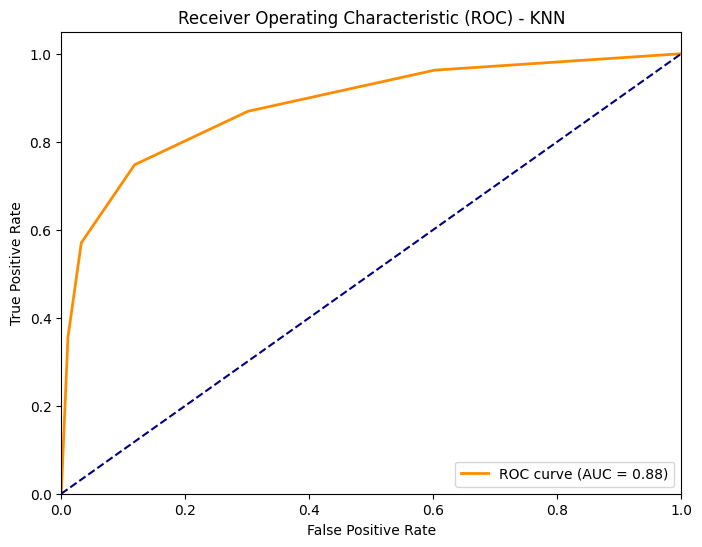

In [439]:
from sklearn.metrics import roc_curve, auc
from sklearn.neighbors import KNeighborsClassifier
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
x, y = make_classification(n_samples=1000, n_features=20, n_classes=2, random_state=42)
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
knn_classifier = KNeighborsClassifier()
knn_classifier.fit(x_train, y_train)
y_score = knn_classifier.predict_proba(x_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_score)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) - KNN')
plt.legend(loc="lower right")
plt.show()


In [440]:
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

x, y = make_classification(n_samples=1000, n_features=20, n_classes=2, random_state=42)

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

model_nn = tf.keras.Sequential([
    tf.keras.layers.Dense(64, activation='relu', input_shape=(20,)),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])
model_nn.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])
early_stopping_nn = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3)
model_nn.fit(x_train, y_train, epochs=50, batch_size=32, validation_data=(x_test, y_test), callbacks=[early_stopping_nn])
model_knn = KNeighborsClassifier()
model_knn.fit(x_train, y_train)
y_pred_knn_train = model_knn.predict(x_train)
y_pred_knn_test = model_knn.predict(x_test)




Epoch 1/50
25/25 [==============================] - 1s 11ms/step - loss: 0.5700 - accuracy: 0.7262 - val_loss: 0.4821 - val_accuracy: 0.7950
Epoch 2/50
25/25 [==============================] - 0s 4ms/step - loss: 0.4117 - accuracy: 0.8637 - val_loss: 0.4097 - val_accuracy: 0.8300
Epoch 3/50
25/25 [==============================] - 0s 4ms/step - loss: 0.3538 - accuracy: 0.8662 - val_loss: 0.3740 - val_accuracy: 0.8600
Epoch 4/50
25/25 [==============================] - 0s 4ms/step - loss: 0.3234 - accuracy: 0.8775 - val_loss: 0.3621 - val_accuracy: 0.8550
Epoch 5/50
25/25 [==============================] - 0s 3ms/step - loss: 0.3057 - accuracy: 0.8838 - val_loss: 0.3550 - val_accuracy: 0.8550
Epoch 6/50
25/25 [==============================] - 0s 4ms/step - loss: 0.2916 - accuracy: 0.8888 - val_loss: 0.3534 - val_accuracy: 0.8400
Epoch 7/50
25/25 [==============================] - 0s 4ms/step - loss: 0.2782 - accuracy: 0.8900 - val_loss: 0.3477 - val_accuracy: 0.8550
Epoch 8/50
25/25 [=

In [441]:
classification_report_str = classification_report(y_test, knn_pred_CV, digits=4)

print("Classification Report for KNN with CV:\n", classification_report_str)

Classification Report for KNN with CV:
               precision    recall  f1-score   support

           0     0.7523    0.8817    0.8119        93
           1     0.8791    0.7477    0.8081       107

    accuracy                         0.8100       200
   macro avg     0.8157    0.8147    0.8100       200
weighted avg     0.8201    0.8100    0.8098       200



Gradient Boosting

In [442]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn import metrics
gbModel = GradientBoostingClassifier()
gbModel.fit(x_train, y_train)
gb_pred = gbModel.predict(x_test)
gb_accuracy = metrics.accuracy_score(y_test, gb_pred) * 100



In [443]:
from sklearn.metrics import accuracy_score
gbModel.fit(x_train, y_train)
y_train_pred = gbModel.predict(x_train)
training_accuracy = accuracy_score(y_train, y_train_pred)

print(f"Training Accuracy: {training_accuracy * 100:.2f}")


Training Accuracy: 99.00


In [444]:
gb_param_grid = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.1, 0.5],
    'max_depth': [3, 5, 7],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
}
gb_best_params = {
    'n_estimators': [100],
    'learning_rate': [0.1],
    'max_depth': [3],
    'min_samples_split': [2],
    'min_samples_leaf': [1],
}
gbModel = GradientBoostingClassifier()
gb_gridsearch = GridSearchCV(estimator=gbModel, param_grid=gb_best_params, cv=5, scoring='accuracy', n_jobs=-1)
gb_gridsearch.fit(x_train, y_train)



GridSearchCV(cv=5, estimator=GradientBoostingClassifier(), n_jobs=-1,
             param_grid={'learning_rate': [0.1], 'max_depth': [3],
                         'min_samples_leaf': [1], 'min_samples_split': [2],
                         'n_estimators': [100]},
             scoring='accuracy')

In [445]:
gb_best_params = gb_gridsearch.best_params_
gb_best_estimator = gb_gridsearch.best_estimator_

print(f"Best Parameters : {gb_best_params}")
print(f"Best Estimator  : {gb_best_estimator}")

Best Parameters : {'learning_rate': 0.1, 'max_depth': 3, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Best Estimator  : GradientBoostingClassifier()


In [446]:
gb_pred_CV = gb_best_estimator.predict(x_test)

In [447]:
gb_accuracy_cv = metrics.accuracy_score(y_test, gb_pred_CV)*100
print(f"Best Accuracy: {gb_accuracy_cv:.2f}")

Best Accuracy: 91.00


Text(0.5, 427.9555555555555, 'Predicted label')

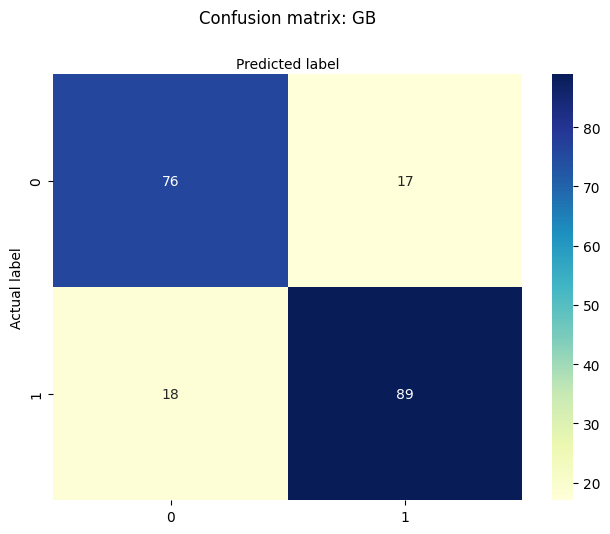

In [448]:
cnf_matrix = metrics.confusion_matrix(y_test, mlp_pred_CV)
cnf_matrix

class_names=[0,1]
fig, ax = splt.subplots()
tick_marks = np.arange(len(class_names))
splt.xticks(tick_marks, class_names)
splt.yticks(tick_marks, class_names)
seaborn.heatmap(pd.DataFrame(cnf_matrix), annot=True, cmap="YlGnBu" ,fmt='g')
ax.xaxis.set_label_position("top")
splt.tight_layout()
splt.title('Confusion matrix: GB', y=1.1)
splt.ylabel('Actual label')
splt.xlabel('Predicted label')

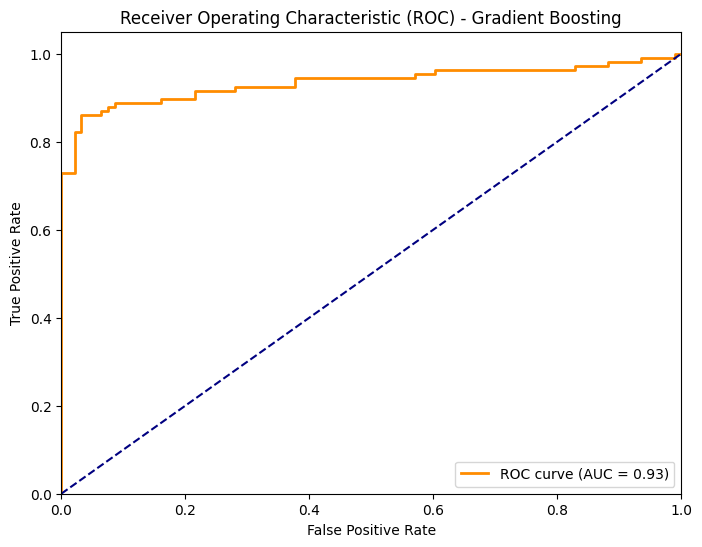

In [449]:
from sklearn.metrics import roc_curve, auc
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
x, y = make_classification(n_samples=1000, n_features=20, n_classes=2, random_state=42)
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
gb_classifier = GradientBoostingClassifier(random_state=42)
gb_classifier.fit(x_train, y_train)
y_score = gb_classifier.predict_proba(x_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_score)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) - Gradient Boosting')
plt.legend(loc="lower right")
plt.show()


In [450]:
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score
x, y = make_classification(n_samples=1000, n_features=20, n_classes=2, random_state=42)
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

model_nn = tf.keras.Sequential([
    tf.keras.layers.Dense(64, activation='relu', input_shape=(20,)),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

model_nn.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])
early_stopping_nn = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3)
model_nn.fit(x_train, y_train, epochs=50, batch_size=32, validation_data=(x_test, y_test), callbacks=[early_stopping_nn])
model_gb = GradientBoostingClassifier(n_estimators=100, random_state=42)
model_gb.fit(x_train, y_train)
y_pred_gb_train = model_gb.predict(x_train)
y_pred_gb_test = model_gb.predict(x_test)



Epoch 1/50
25/25 [==============================] - 1s 17ms/step - loss: 0.5994 - accuracy: 0.7325 - val_loss: 0.4951 - val_accuracy: 0.8200
Epoch 2/50
25/25 [==============================] - 0s 6ms/step - loss: 0.4226 - accuracy: 0.8475 - val_loss: 0.4035 - val_accuracy: 0.8450
Epoch 3/50
25/25 [==============================] - 0s 7ms/step - loss: 0.3406 - accuracy: 0.8687 - val_loss: 0.3690 - val_accuracy: 0.8550
Epoch 4/50
25/25 [==============================] - 0s 6ms/step - loss: 0.3043 - accuracy: 0.8875 - val_loss: 0.3548 - val_accuracy: 0.8550
Epoch 5/50
25/25 [==============================] - 0s 6ms/step - loss: 0.2849 - accuracy: 0.8925 - val_loss: 0.3569 - val_accuracy: 0.8650
Epoch 6/50
25/25 [==============================] - 0s 5ms/step - loss: 0.2723 - accuracy: 0.8963 - val_loss: 0.3495 - val_accuracy: 0.8750
Epoch 7/50
25/25 [==============================] - 0s 6ms/step - loss: 0.2608 - accuracy: 0.9025 - val_loss: 0.3496 - val_accuracy: 0.8550
Epoch 8/50
25/25 [=

In [451]:
classification_report_str = classification_report(y_test, gb_pred_CV, digits=4)

print("Classification Report for GB with CV:\n", classification_report_str)

Classification Report for GB with CV:
               precision    recall  f1-score   support

           0     0.8571    0.9677    0.9091        93
           1     0.9684    0.8598    0.9109       107

    accuracy                         0.9100       200
   macro avg     0.9128    0.9138    0.9100       200
weighted avg     0.9167    0.9100    0.9101       200



Accuracy of all five models

In [452]:
print(f"RF accuracy    : {rf_accuracy_cv:.2f}")
print(f"MLP accuracy   : {mlp_accuracy_cv:.2f}")
print(f"SVM accuracy   : {svm_accuracy_cv:.2f}")
print(f"KNN accuracy   : {knn_accuracy_cv:.2f}")
print(f"GB accuracy    : {gb_accuracy_cv:.2f}")


RF accuracy    : 87.82
MLP accuracy   : 82.50
SVM accuracy   : 85.50
KNN accuracy   : 81.00
GB accuracy    : 91.00


Comparison of five models

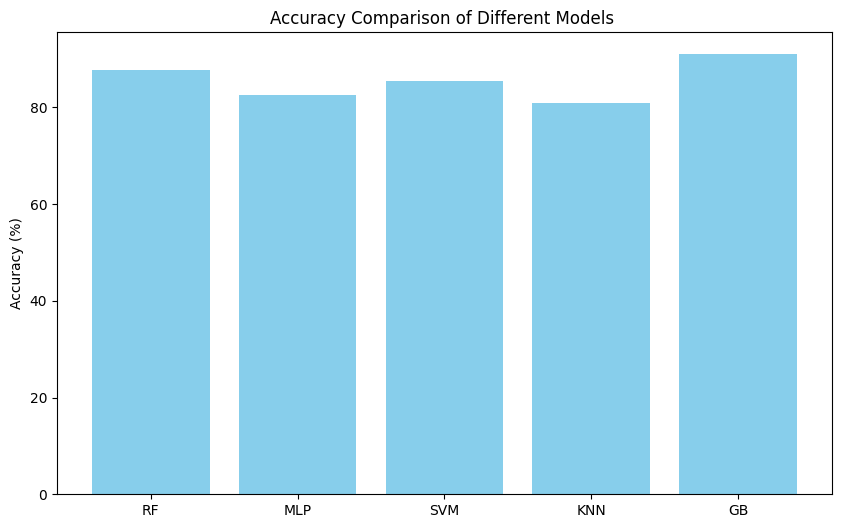

In [454]:
models = ['RF', 'MLP', 'SVM', 'KNN', 'GB']
accuracies = [87.82, 82.50, 85.50, 81.00, 91.00]
splt.figure(figsize=(10, 6))
splt.bar(models, accuracies, color='skyblue')
splt.ylabel('Accuracy (%)')
splt.title('Accuracy Comparison of Different Models ')
splt.show()
